# SaaS Subscription Analytics with SQL: Revenue, Churn & Customer Behavior

## Project Overview

This project analyzes a synthetic SaaS dataset for RavenStack, a fictional AI-powered collaboration platform. The analysis focuses on recurring revenue, customer churn, subscription behavior, support experience, and product usage.

The main goal is to identify which customer segments generate the most revenue, which groups are more likely to churn, and what business actions could improve retention and subscription performance.

## Dataset Credit

Dataset: SaaS Subscription & Churn Analytics Dataset  
Author: River @ Rivalytics  
Source: Kaggle  

The dataset is fully synthetic and contains no real personal information.

## Business Questions

1. Which subscription plans generate the most MRR and ARR?
2. What is the overall churn rate?
3. Which customer segments have the highest churn?
4. How do billing frequency, plan tier, and referral source relate to churn?
5. Do support tickets and satisfaction scores differ between churned and retained customers?
6. Which product features are used most often?
7. Do churned customers show different feature usage patterns?
8. What business recommendations can be made to improve retention and revenue?

# Imports

In [44]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_accounts.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/README.md
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_feature_usage.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_support_tickets.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_subscriptions.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_churn_events.csv


In [45]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [46]:
base_path = '/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset'

ravenstack_accounts = pd.read_csv(f'{base_path}/ravenstack_accounts.csv')
ravenstack_subscriptions = pd.read_csv(f'{base_path}/ravenstack_subscriptions.csv')
ravenstack_feature_usage = pd.read_csv(f'{base_path}/ravenstack_feature_usage.csv')
ravenstack_support_tickets = pd.read_csv(f'{base_path}/ravenstack_support_tickets.csv')
ravenstack_churn_events = pd.read_csv(f'{base_path}/ravenstack_churn_events.csv')

In [47]:
conn = sqlite3.connect(':memory:')

ravenstack_accounts.to_sql('ravenstack_accounts', conn, index=False, if_exists='replace')
ravenstack_subscriptions.to_sql('ravenstack_subscriptions', conn, index=False, if_exists='replace')
ravenstack_feature_usage.to_sql('ravenstack_feature_usage', conn, index=False, if_exists='replace')
ravenstack_support_tickets.to_sql('ravenstack_support_tickets', conn, index=False, if_exists='replace')
ravenstack_churn_events.to_sql('ravenstack_churn_events', conn, index=False, if_exists='replace')

600

In [48]:
def run_query(query):
    return pd.read_sql_query(query, conn)

# Data Overview
Before answering business questions, I first check the database structure, table sizes, key columns, and basic data quality issues using SQL.

In [49]:
query = """
SELECT name 
FROM sqlite_master 
WHERE type = 'table';
"""

run_query(query)

,name
0,ravenstack_accounts
1,ravenstack_subscriptions
2,ravenstack_feature_usage
3,ravenstack_support_tickets
4,ravenstack_churn_events


In [50]:
query = """
SELECT 'accounts' AS table_name, COUNT(*) AS row_count FROM ravenstack_accounts
UNION ALL
SELECT 'subscriptions' AS table_name, COUNT(*) AS row_count FROM ravenstack_subscriptions
UNION ALL
SELECT 'feature_usage' AS table_name, COUNT(*) AS row_count FROM ravenstack_feature_usage
UNION ALL
SELECT 'support_tickets' AS table_name, COUNT(*) AS row_count FROM ravenstack_support_tickets
UNION ALL
SELECT 'churn_events' AS table_name, COUNT(*) AS row_count FROM ravenstack_churn_events;
"""

run_query(query)

,table_name,row_count
0,accounts,500
1,subscriptions,5000
2,feature_usage,25000
3,support_tickets,2000
4,churn_events,600


The dataset consists of five related tables: customer accounts, subscriptions, product usage events, support tickets, and churn events. This structure allows the analysis to connect revenue, customer behavior, support experience, and churn outcomes.

In [51]:
query = """
PRAGMA table_info(ravenstack_accounts);
"""

run_query(query)

,cid,name,type,notnull,dflt_value,pk
0,0,account_id,TEXT,0,None,0
1,1,account_name,TEXT,0,None,0
2,2,industry,TEXT,0,None,0
3,3,country,TEXT,0,None,0
4,4,signup_date,TEXT,0,None,0
5,5,referral_source,TEXT,0,None,0
6,6,plan_tier,TEXT,0,None,0
7,7,seats,INTEGER,0,None,0
8,8,is_trial,INTEGER,0,None,0
9,9,churn_flag,INTEGER,0,None,0


In [52]:
query = """
PRAGMA table_info(ravenstack_subscriptions);
"""

run_query(query)

,cid,name,type,notnull,dflt_value,pk
0,0,subscription_id,TEXT,0,None,0
1,1,account_id,TEXT,0,None,0
2,2,start_date,TEXT,0,None,0
3,3,end_date,TEXT,0,None,0
4,4,plan_tier,TEXT,0,None,0
5,5,seats,INTEGER,0,None,0
6,6,mrr_amount,INTEGER,0,None,0
7,7,arr_amount,INTEGER,0,None,0
8,8,is_trial,INTEGER,0,None,0
9,9,upgrade_flag,INTEGER,0,None,0


In [53]:
query = """
PRAGMA table_info(ravenstack_feature_usage);
"""

run_query(query)

,cid,name,type,notnull,dflt_value,pk
0,0,usage_id,TEXT,0,None,0
1,1,subscription_id,TEXT,0,None,0
2,2,usage_date,TEXT,0,None,0
3,3,feature_name,TEXT,0,None,0
4,4,usage_count,INTEGER,0,None,0
5,5,usage_duration_secs,INTEGER,0,None,0
6,6,error_count,INTEGER,0,None,0
7,7,is_beta_feature,INTEGER,0,None,0


In [54]:
query = """
PRAGMA table_info(ravenstack_support_tickets);
"""

run_query(query)

,cid,name,type,notnull,dflt_value,pk
0,0,ticket_id,TEXT,0,None,0
1,1,account_id,TEXT,0,None,0
2,2,submitted_at,TEXT,0,None,0
3,3,closed_at,TEXT,0,None,0
4,4,resolution_time_hours,REAL,0,None,0
5,5,priority,TEXT,0,None,0
6,6,first_response_time_minutes,INTEGER,0,None,0
7,7,satisfaction_score,REAL,0,None,0
8,8,escalation_flag,INTEGER,0,None,0


In [55]:
query = """
PRAGMA table_info(ravenstack_churn_events);
"""

run_query(query)

,cid,name,type,notnull,dflt_value,pk
0,0,churn_event_id,TEXT,0,None,0
1,1,account_id,TEXT,0,None,0
2,2,churn_date,TEXT,0,None,0
3,3,reason_code,TEXT,0,None,0
4,4,refund_amount_usd,REAL,0,None,0
5,5,preceding_upgrade_flag,INTEGER,0,None,0
6,6,preceding_downgrade_flag,INTEGER,0,None,0
7,7,is_reactivation,INTEGER,0,None,0
8,8,feedback_text,TEXT,0,None,0


# Checking connections

In [56]:
#Accounts without subscriptions
query = """
SELECT 
    COUNT(*) AS accounts_without_subscriptions
FROM ravenstack_accounts a
LEFT JOIN ravenstack_subscriptions s
    ON a.account_id = s.account_id
WHERE s.subscription_id IS NULL;
"""

run_query(query)

,accounts_without_subscriptions
0,0


In [57]:
#Subscriptions without accounts
query = """
SELECT 
    COUNT(*) AS subscriptions_without_accounts
FROM ravenstack_subscriptions s
LEFT JOIN ravenstack_accounts a
    ON s.account_id = a.account_id
WHERE a.account_id IS NULL;
"""

run_query(query)

,subscriptions_without_accounts
0,0


In [58]:
#Feature usage records without subscriptions
query = """
SELECT 
    COUNT(*) AS usage_records_without_subscription
FROM ravenstack_feature_usage fu
LEFT JOIN ravenstack_subscriptions s
    ON fu.subscription_id = s.subscription_id
WHERE s.subscription_id IS NULL;
"""

run_query(query)

,usage_records_without_subscription
0,0


The relationship check confirms whether foreign keys are complete across the dataset. This is important because revenue, churn, support, and usage analyses rely on correctly joined tables.

# Data & Performance Analysis

## Revenue Overview

The first part of the analysis focuses on recurring revenue. For a SaaS business, MRR and ARR are core indicators of business performance.

In [59]:
#Basic revenue overview
query = """
SELECT
    COUNT(DISTINCT subscription_id) AS total_subscriptions,
    COUNT(DISTINCT account_id) AS total_accounts,
    ROUND(SUM(mrr_amount), 2) AS total_mrr,
    ROUND(AVG(mrr_amount), 2) AS avg_mrr_per_subscription,
    ROUND(SUM(arr_amount), 2) AS total_arr,
    ROUND(AVG(arr_amount), 2) AS avg_arr_per_subscription
FROM ravenstack_subscriptions;
"""

run_query(query)

,total_subscriptions,total_accounts,total_mrr,avg_mrr_per_subscription,total_arr,avg_arr_per_subscription
0,5000,500,11338747.0,2267.75,136064964.0,27212.99


The previous revenue overview shows total revenue across all subscription records.  
To estimate current recurring revenue more accurately, I also calculate active MRR using subscriptions that are still active.

In [60]:
query = """
SELECT
    COUNT(DISTINCT subscription_id) AS active_subscriptions,
    COUNT(DISTINCT account_id) AS active_accounts,
    ROUND(SUM(mrr_amount), 2) AS active_mrr,
    ROUND(AVG(mrr_amount), 2) AS avg_active_mrr_per_subscription,
    ROUND(SUM(arr_amount), 2) AS active_arr
FROM ravenstack_subscriptions
WHERE end_date IS NULL
   AND churn_flag = 0;
"""

active_revenue_overview = run_query(query)
active_revenue_overview

,active_subscriptions,active_accounts,active_mrr,avg_active_mrr_per_subscription,active_arr
0,4514,500,10159608.0,2250.69,121915296.0


## Active MRR by Plan Tier

This query shows which subscription plans currently generate the most recurring revenue among active subscriptions.

In [61]:
query = """
SELECT
    plan_tier,
    COUNT(DISTINCT subscription_id) AS active_subscriptions,
    COUNT(DISTINCT account_id) AS active_accounts,
    ROUND(SUM(mrr_amount), 2) AS active_mrr,
    ROUND(AVG(mrr_amount), 2) AS avg_active_mrr
FROM ravenstack_subscriptions
WHERE end_date IS NULL
  AND churn_flag = 0
GROUP BY plan_tier
ORDER BY active_mrr DESC;
"""

active_revenue_by_plan = run_query(query)
active_revenue_by_plan

,plan_tier,active_subscriptions,active_accounts,active_mrr,avg_active_mrr
0,Enterprise,1551,474,7546876.0,4865.81
1,Pro,1513,468,1924818.0,1272.19
2,Basic,1450,472,687914.0,474.42


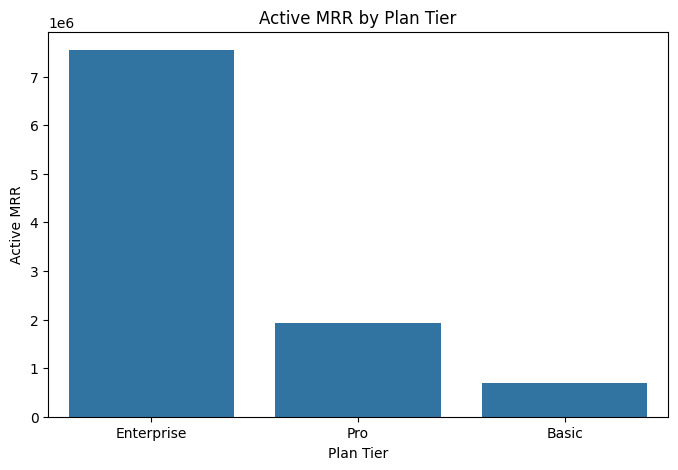

In [62]:
plt.figure(figsize=(8, 5))
sns.barplot(data=active_revenue_by_plan, x='plan_tier', y='active_mrr')
plt.title('Active MRR by Plan Tier')
plt.xlabel('Plan Tier')
plt.ylabel('Active MRR')
plt.show()

Enterprise remains the strongest active revenue driver, which confirms that this segment is not only historically important but also central to current recurring revenue.

## Revenue by plan tier

In [63]:
query = """
SELECT
    plan_tier,
    COUNT(DISTINCT subscription_id) AS subscriptions_count,
    COUNT(DISTINCT account_id) AS accounts_count,
    ROUND(SUM(mrr_amount), 2) AS total_mrr,
    ROUND(AVG(mrr_amount), 2) AS avg_mrr,
    ROUND(SUM(arr_amount), 2) AS total_arr,
    ROUND(AVG(arr_amount), 2) AS avg_arr
FROM ravenstack_subscriptions
GROUP BY plan_tier
ORDER BY total_mrr DESC;
"""

revenue_by_plan = run_query(query)
revenue_by_plan

,plan_tier,subscriptions_count,accounts_count,total_mrr,avg_mrr,total_arr,avg_arr
0,Enterprise,1723,479,8473221.0,4917.71,101678652.0,59012.57
1,Pro,1675,474,2105089.0,1256.77,25261068.0,15081.23
2,Basic,1602,480,760437.0,474.68,9125244.0,5696.16


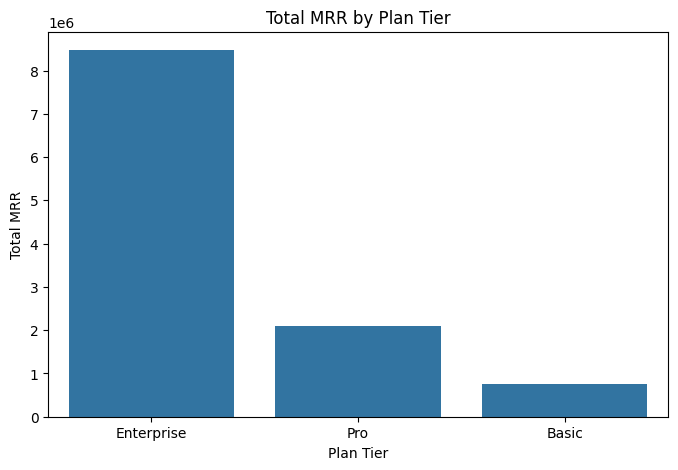

In [64]:
plt.figure(figsize=(8, 5))
sns.barplot(data=revenue_by_plan, x='plan_tier', y='total_mrr')
plt.title('Total MRR by Plan Tier')
plt.xlabel('Plan Tier')
plt.ylabel('Total MRR')
plt.show()

Enterprise is the strongest revenue driver, generating the largest share of total MRR and ARR. Although the number of subscriptions is relatively similar across plan tiers, Enterprise has a much higher average MRR, which makes it the most financially important customer segment.

## Revenue by billing frequency

In [65]:
query = """
SELECT
    billing_frequency,
    COUNT(DISTINCT subscription_id) AS subscriptions_count,
    COUNT(DISTINCT account_id) AS accounts_count,
    ROUND(SUM(mrr_amount), 2) AS total_mrr,
    ROUND(AVG(mrr_amount), 2) AS avg_mrr,
    ROUND(SUM(arr_amount), 2) AS total_arr
FROM ravenstack_subscriptions
GROUP BY billing_frequency
ORDER BY total_mrr DESC;
"""

revenue_by_billing = run_query(query)
revenue_by_billing

,billing_frequency,subscriptions_count,accounts_count,total_mrr,avg_mrr,total_arr
0,monthly,2539,499,5741349.0,2261.26,68896188.0
1,annual,2461,498,5597398.0,2274.44,67168776.0


Revenue is almost evenly split between monthly and annual billing. This suggests that both billing models are important for the business. However, annual billing may still be strategically valuable because it usually indicates stronger customer commitment and more predictable cash flow.

## Churn Overview

Churn rate measures the share of accounts that left the product. For a subscription business, churn directly affects recurring revenue, customer lifetime value, and growth efficiency.

## Overall churn rate

In [66]:
query = """
SELECT
    COUNT(DISTINCT account_id) AS total_accounts,
    COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END) AS churned_accounts,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END) 
        / COUNT(DISTINCT account_id), 
        2
    ) AS churn_rate_percent
FROM ravenstack_accounts;
"""

overall_churn = run_query(query)
overall_churn

,total_accounts,churned_accounts,churn_rate_percent
0,500,110,22.0


## Churn by initial plan tier

In [67]:
query = """
SELECT
    plan_tier,
    COUNT(DISTINCT account_id) AS total_accounts,
    COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END) AS churned_accounts,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END) 
        / COUNT(DISTINCT account_id), 
        2
    ) AS churn_rate_percent
FROM ravenstack_accounts
GROUP BY plan_tier
ORDER BY churn_rate_percent DESC;
"""

churn_by_plan = run_query(query)
churn_by_plan

,plan_tier,total_accounts,churned_accounts,churn_rate_percent
0,Enterprise,154,34,22.08
1,Basic,168,37,22.02
2,Pro,178,39,21.91


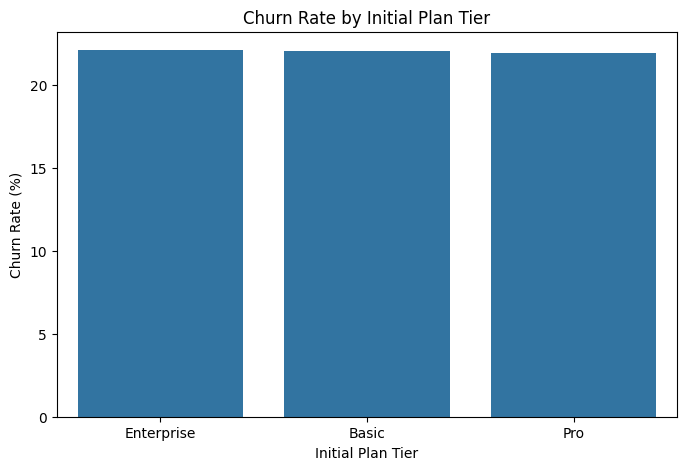

In [68]:
plt.figure(figsize=(8, 5))
sns.barplot(data=churn_by_plan, x='plan_tier', y='churn_rate_percent')
plt.title('Churn Rate by Initial Plan Tier')
plt.xlabel('Initial Plan Tier')
plt.ylabel('Churn Rate (%)')
plt.show()

The overall account churn rate is 22%. This means that roughly one in five accounts churned at some point. For a subscription-based SaaS business, this is a meaningful retention risk because churn directly reduces recurring revenue and customer lifetime value.
Churn rates are almost identical across initial plan tiers. This suggests that churn is probably not driven mainly by the initial plan tier. Instead, other factors such as acquisition channel, industry, onboarding quality, support experience, or product usage may explain churn differences better.

# Customer Segmentation

In this section, I analyze how churn and revenue differ across customer segments such as industry, referral source, country, trial status, and seat count.

This helps identify which types of customers are more valuable and which groups may require stronger onboarding, support, or retention efforts.

## Revenue and churn by industry

In [69]:
query = """
SELECT
    a.industry,
    COUNT(DISTINCT a.account_id) AS total_accounts,
    COUNT(DISTINCT CASE WHEN a.churn_flag = 1 THEN a.account_id END) AS churned_accounts,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN a.churn_flag = 1 THEN a.account_id END)
        / COUNT(DISTINCT a.account_id),
        2
    ) AS churn_rate_percent,
    ROUND(SUM(s.mrr_amount), 2) AS total_mrr,
    ROUND(AVG(s.mrr_amount), 2) AS avg_mrr
FROM ravenstack_accounts a
LEFT JOIN ravenstack_subscriptions s
    ON a.account_id = s.account_id
GROUP BY a.industry
ORDER BY total_mrr DESC;
"""

industry_analysis = run_query(query)
industry_analysis

,industry,total_accounts,churned_accounts,churn_rate_percent,total_mrr,avg_mrr
0,FinTech,112,25,22.32,2669496.0,2426.81
1,DevTools,113,35,30.97,2403654.0,2075.69
2,Cybersecurity,100,16,16.00,2253318.0,2235.43
3,EdTech,79,13,16.46,2043167.0,2602.76
4,HealthTech,96,21,21.88,1969112.0,2074.93


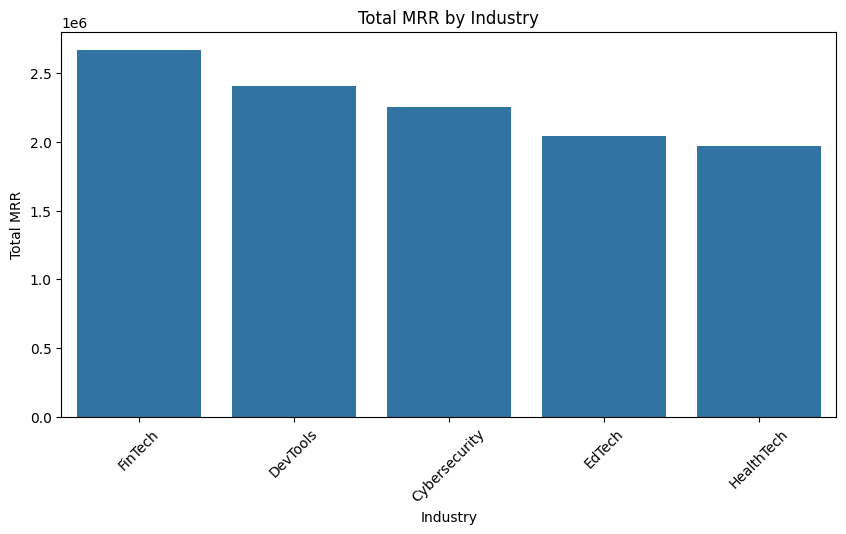

In [70]:
plt.figure(figsize=(10, 5))
sns.barplot(data=industry_analysis, x='industry', y='total_mrr')
plt.title('Total MRR by Industry')
plt.xlabel('Industry')
plt.ylabel('Total MRR')
plt.xticks(rotation=45)
plt.show()

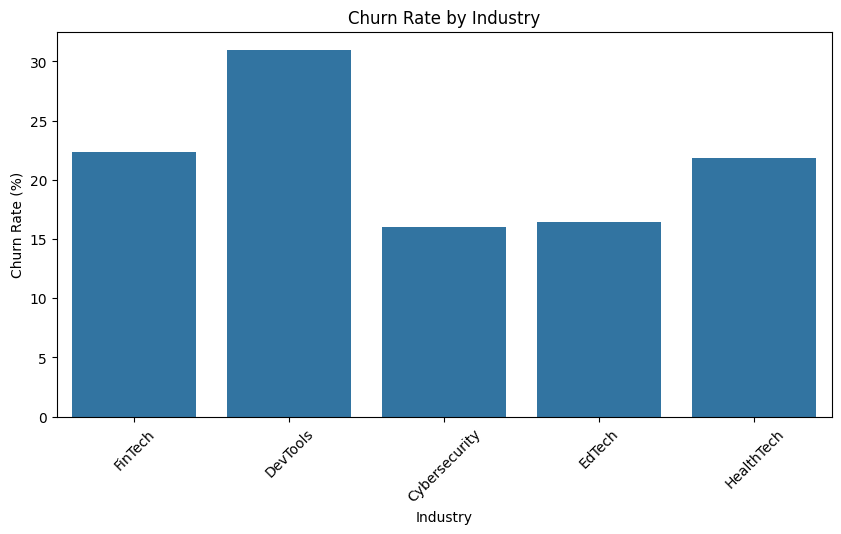

In [71]:
plt.figure(figsize=(10, 5))
sns.barplot(data=industry_analysis, x='industry', y='churn_rate_percent')
plt.title('Churn Rate by Industry')
plt.xlabel('Industry')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

FinTech generates the highest total MRR, while DevTools has the highest churn rate. This indicates that revenue concentration and retention risk are not the same across industries. DevTools may require closer investigation, while FinTech appears to be one of the most valuable segments from a revenue perspective.

## Revenue and churn by referral source

In [72]:
query = """
SELECT
    a.referral_source,
    COUNT(DISTINCT a.account_id) AS total_accounts,
    COUNT(DISTINCT CASE WHEN a.churn_flag = 1 THEN a.account_id END) AS churned_accounts,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN a.churn_flag = 1 THEN a.account_id END)
        / COUNT(DISTINCT a.account_id),
        2
    ) AS churn_rate_percent,
    ROUND(SUM(s.mrr_amount), 2) AS total_mrr,
    ROUND(AVG(s.mrr_amount), 2) AS avg_mrr
FROM ravenstack_accounts a
LEFT JOIN ravenstack_subscriptions s
    ON a.account_id = s.account_id
GROUP BY a.referral_source
ORDER BY total_mrr DESC;
"""

referral_analysis = run_query(query)
referral_analysis

,referral_source,total_accounts,churned_accounts,churn_rate_percent,total_mrr,avg_mrr
0,organic,114,20,17.54,2798707.0,2392.06
1,other,103,25,24.27,2377728.0,2315.22
2,ads,98,23,23.47,2146619.0,2146.62
3,partner,89,13,14.61,2094243.0,2363.71
4,event,96,29,30.21,1921450.0,2095.37


This query compares acquisition channels by revenue contribution and churn rate. Referral source analysis helps evaluate whether some channels bring higher-value or more stable customers.

Referral source shows a stronger churn difference than plan tier. Accounts acquired through events have the highest churn rate, while partner-sourced accounts have the lowest churn rate. This may indicate that partner acquisition brings more qualified or better-fit customers, while event leads may require stronger onboarding and qualification.

## Churn by trial status

In [73]:
query = """
SELECT
    is_trial,
    COUNT(DISTINCT account_id) AS total_accounts,
    COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END) AS churned_accounts,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END)
        / COUNT(DISTINCT account_id),
        2
    ) AS churn_rate_percent
FROM ravenstack_accounts
GROUP BY is_trial
ORDER BY churn_rate_percent DESC;
"""

trial_churn = run_query(query)
trial_churn

,is_trial,total_accounts,churned_accounts,churn_rate_percent
0,1,97,25,25.77
1,0,403,85,21.09


Trial status can be an important retention signal. If trial accounts churn more often, this may indicate onboarding issues, unclear product value, or weak trial-to-paid conversion quality.

Trial accounts have a higher churn rate than non-trial accounts. This may suggest that some trial users do not fully experience the product value before converting or that the onboarding process for trial users needs improvement.

## Seat count segmentation

In [74]:
query = """
WITH account_segments AS (
    SELECT
        account_id,
        seats,
        churn_flag,
        CASE
            WHEN seats <= 5 THEN 'Small team'
            WHEN seats BETWEEN 6 AND 20 THEN 'Mid-size team'
            ELSE 'Large team'
        END AS seat_segment
    FROM ravenstack_accounts
)

SELECT
    seat_segment,
    COUNT(DISTINCT account_id) AS total_accounts,
    COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END) AS churned_accounts,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END)
        / COUNT(DISTINCT account_id),
        2
    ) AS churn_rate_percent,
    ROUND(AVG(seats), 2) AS avg_seats
FROM account_segments
GROUP BY seat_segment
ORDER BY churn_rate_percent DESC;
"""

seat_segment_churn = run_query(query)
seat_segment_churn

,seat_segment,total_accounts,churned_accounts,churn_rate_percent,avg_seats
0,Mid-size team,188,47,25.00,12.55
1,Small team,126,26,20.63,2.84
2,Large team,186,37,19.89,40.66


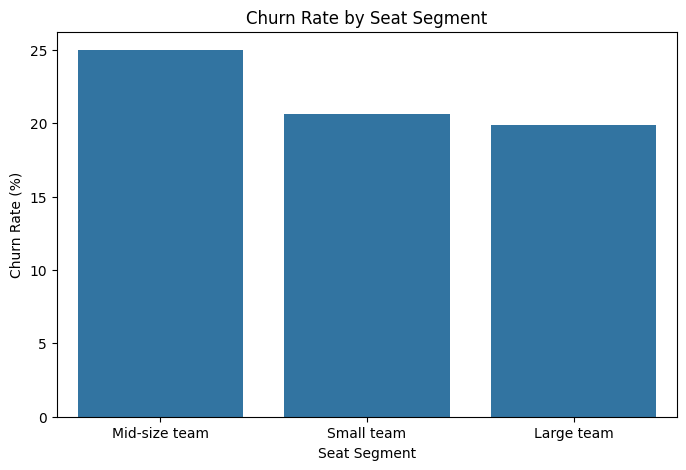

In [75]:
plt.figure(figsize=(8, 5))
sns.barplot(data=seat_segment_churn, x='seat_segment', y='churn_rate_percent')
plt.title('Churn Rate by Seat Segment')
plt.xlabel('Seat Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

Mid-size teams have the highest churn rate, while large teams show the lowest churn rate. This may indicate that larger customers are more committed once they adopt the product, while mid-size teams may be more sensitive to value perception, pricing, or implementation friction.

# Support Experience and Churn

This section explores whether support experience differs between churned and retained customers. For a SaaS company, poor support experience may increase churn risk, especially when customers face unresolved issues, slow response times, or escalations.

## Support metrics by churn status

In [76]:
query = """
SELECT
    a.churn_flag,
    COUNT(DISTINCT a.account_id) AS total_accounts,
    COUNT(t.ticket_id) AS total_tickets,
    ROUND(1.0 * COUNT(t.ticket_id) / COUNT(DISTINCT a.account_id), 2) AS avg_tickets_per_account,
    ROUND(AVG(t.resolution_time_hours), 2) AS avg_resolution_time_hours,
    ROUND(AVG(t.first_response_time_minutes), 2) AS avg_first_response_time_minutes,
    ROUND(AVG(t.satisfaction_score), 2) AS avg_satisfaction_score,
    ROUND(
        100.0 * SUM(CASE WHEN t.escalation_flag = 1 THEN 1 ELSE 0 END)
        / COUNT(t.ticket_id),
        2
    ) AS escalation_rate_percent
FROM ravenstack_accounts a
LEFT JOIN ravenstack_support_tickets t
    ON a.account_id = t.account_id
GROUP BY a.churn_flag;
"""

support_by_churn = run_query(query)
support_by_churn

,churn_flag,total_accounts,total_tickets,avg_tickets_per_account,avg_resolution_time_hours,avg_first_response_time_minutes,avg_satisfaction_score,escalation_rate_percent
0,0,390,1568,4.02,35.92,89.50,3.97,4.53
1,1,110,432,3.93,35.66,84.78,4.01,5.56


## Churn by satisfaction level

In [77]:
query = """
WITH account_support AS (
    SELECT
        a.account_id,
        a.churn_flag,
        AVG(t.satisfaction_score) AS avg_satisfaction_score
    FROM ravenstack_accounts a
    LEFT JOIN ravenstack_support_tickets t
        ON a.account_id = t.account_id
    GROUP BY a.account_id, a.churn_flag
),

satisfaction_segments AS (
    SELECT
        account_id,
        churn_flag,
        CASE
            WHEN avg_satisfaction_score IS NULL THEN 'No score'
            WHEN avg_satisfaction_score < 3 THEN 'Low satisfaction'
            WHEN avg_satisfaction_score < 4 THEN 'Medium satisfaction'
            ELSE 'High satisfaction'
        END AS satisfaction_segment
    FROM account_support
)

SELECT
    satisfaction_segment,
    COUNT(DISTINCT account_id) AS total_accounts,
    COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END) AS churned_accounts,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN churn_flag = 1 THEN account_id END)
        / COUNT(DISTINCT account_id),
        2
    ) AS churn_rate_percent
FROM satisfaction_segments
GROUP BY satisfaction_segment
ORDER BY churn_rate_percent DESC;
"""

satisfaction_churn = run_query(query)
satisfaction_churn

,satisfaction_segment,total_accounts,churned_accounts,churn_rate_percent
0,No score,34,8,23.53
1,High satisfaction,297,66,22.22
2,Medium satisfaction,169,36,21.30


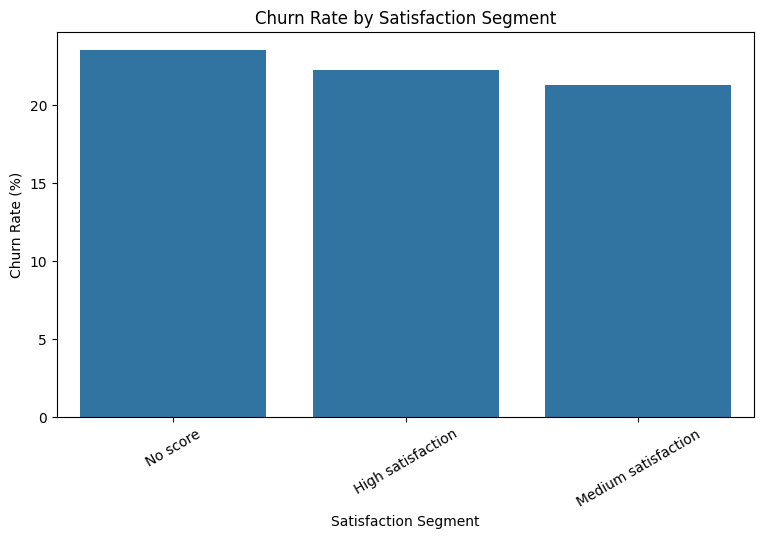

In [78]:
plt.figure(figsize=(9, 5))
sns.barplot(data=satisfaction_churn, x='satisfaction_segment', y='churn_rate_percent')
plt.title('Churn Rate by Satisfaction Segment')
plt.xlabel('Satisfaction Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30)
plt.show()

Support metrics are relatively similar between churned and retained accounts. Churned accounts have a slightly higher escalation rate, but their average satisfaction score and response metrics are not worse. Based on this dataset, support experience does not appear to be the primary churn driver, although escalations may still be worth monitoring.

# Feature Usage Analysis

This section analyzes product engagement patterns. Feature usage can help identify which product areas drive engagement and whether churned customers behave differently from retained customers.

## Most used features

In [79]:
query = """
SELECT
    feature_name,
    COUNT(*) AS usage_events,
    SUM(usage_count) AS total_usage_count,
    ROUND(AVG(usage_duration_secs), 2) AS avg_usage_duration_secs,
    SUM(error_count) AS total_errors
FROM ravenstack_feature_usage
GROUP BY feature_name
ORDER BY total_usage_count DESC
LIMIT 10;
"""

top_features = run_query(query)
top_features

,feature_name,usage_events,total_usage_count,avg_usage_duration_secs,total_errors
0,feature_32,659,6686,3114.29,357
1,feature_15,640,6621,3073.42,349
2,feature_6,655,6546,3074.77,339
3,feature_20,643,6541,3028.29,308
4,feature_34,650,6536,3087.26,397
5,feature_12,659,6534,3128.20,359
6,feature_11,643,6533,3130.29,352
7,feature_2,642,6525,3015.10,401
8,feature_38,643,6478,3020.62,356
9,feature_26,649,6470,3045.27,417


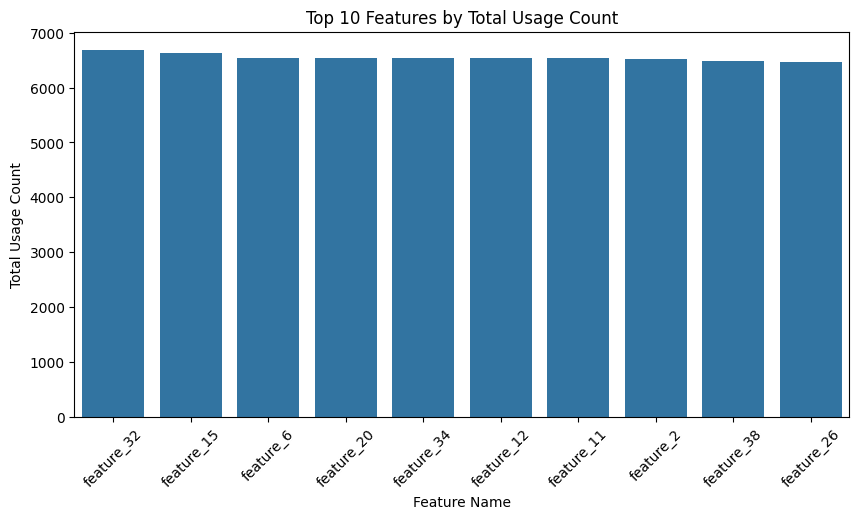

In [80]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_features, x='feature_name', y='total_usage_count')
plt.title('Top 10 Features by Total Usage Count')
plt.xlabel('Feature Name')
plt.ylabel('Total Usage Count')
plt.xticks(rotation=45)
plt.show()

## Feature usage by churn status

In [81]:
query = """
SELECT
    a.churn_flag,
    COUNT(fu.usage_id) AS usage_events,
    SUM(fu.usage_count) AS total_usage_count,
    ROUND(AVG(fu.usage_duration_secs), 2) AS avg_usage_duration_secs,
    SUM(fu.error_count) AS total_errors,
    ROUND(AVG(fu.error_count), 2) AS avg_errors_per_event
FROM ravenstack_accounts a
LEFT JOIN ravenstack_subscriptions s
    ON a.account_id = s.account_id
LEFT JOIN ravenstack_feature_usage fu
    ON s.subscription_id = fu.subscription_id
GROUP BY a.churn_flag;
"""

usage_by_churn = run_query(query)
usage_by_churn

,churn_flag,usage_events,total_usage_count,avg_usage_duration_secs,total_errors,avg_errors_per_event
0,0,19275,193101,3042.12,11010,0.57
1,1,5725,57424,3042.49,3097,0.54


In [82]:
query = """
WITH account_usage AS (
    SELECT
        a.account_id,
        a.churn_flag,
        COUNT(fu.usage_id) AS usage_events,
        COALESCE(SUM(fu.usage_count), 0) AS total_usage_count,
        COALESCE(SUM(fu.error_count), 0) AS total_errors,
        AVG(fu.usage_duration_secs) AS avg_usage_duration_secs
    FROM ravenstack_accounts a
    LEFT JOIN ravenstack_subscriptions s
        ON a.account_id = s.account_id
    LEFT JOIN ravenstack_feature_usage fu
        ON s.subscription_id = fu.subscription_id
    GROUP BY a.account_id, a.churn_flag
)

SELECT
    churn_flag,
    COUNT(DISTINCT account_id) AS total_accounts,
    ROUND(AVG(usage_events), 2) AS avg_usage_events_per_account,
    ROUND(AVG(total_usage_count), 2) AS avg_usage_count_per_account,
    ROUND(AVG(total_errors), 2) AS avg_errors_per_account,
    ROUND(AVG(avg_usage_duration_secs), 2) AS avg_usage_duration_secs
FROM account_usage
GROUP BY churn_flag;
"""

usage_per_account_by_churn = run_query(query)
usage_per_account_by_churn

,churn_flag,total_accounts,avg_usage_events_per_account,avg_usage_count_per_account,avg_errors_per_account,avg_usage_duration_secs
0,0,390,49.42,495.13,28.23,3056.90
1,1,110,52.05,522.04,28.15,3054.28


Although retained accounts generate more total usage events overall, this is mainly because there are more retained accounts in the dataset. After normalizing usage per account, churned accounts actually show slightly higher average usage events and usage count per account.

This suggests that churn is not simply caused by low product engagement. Some customers may churn despite active usage, which could point to issues with pricing, missing features, competitive alternatives, or unmet expectations rather than lack of adoption.

## Churn Reasons

To better understand why customers leave, I analyze churn events by reason code, refund amount, and whether churn was preceded by an upgrade or downgrade.

In [83]:
query = """
SELECT
    reason_code,
    COUNT(*) AS churn_events,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM ravenstack_churn_events), 2) AS share_percent,
    ROUND(AVG(refund_amount_usd), 2) AS avg_refund_amount
FROM ravenstack_churn_events
GROUP BY reason_code
ORDER BY churn_events DESC;
"""

churn_reasons = run_query(query)
churn_reasons

,reason_code,churn_events,share_percent,avg_refund_amount
0,features,114,19.00,16.72
1,support,104,17.33,11.73
2,budget,104,17.33,12.00
3,unknown,95,15.83,18.34
4,competitor,92,15.33,13.08
5,pricing,91,15.17,14.65


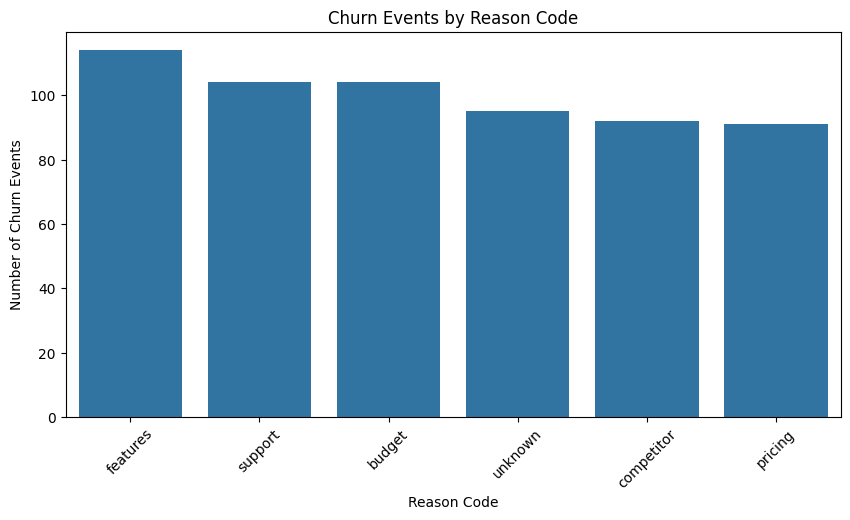

In [84]:
plt.figure(figsize=(10, 5))
sns.barplot(data=churn_reasons, x='reason_code', y='churn_events')
plt.title('Churn Events by Reason Code')
plt.xlabel('Reason Code')
plt.ylabel('Number of Churn Events')
plt.xticks(rotation=45)
plt.show()

The most common churn reason is related to features, followed by support and budget. Pricing is not the leading churn reason in this dataset, although it still represents a meaningful share of churn events.

This suggests that retention efforts should focus not only on pricing, but also on product value, feature completeness, and customer support experience.

## Churn after upgrade/downgrade

In [85]:
query = """
SELECT
    preceding_upgrade_flag,
    preceding_downgrade_flag,
    COUNT(*) AS churn_events,
    ROUND(AVG(refund_amount_usd), 2) AS avg_refund_amount
FROM ravenstack_churn_events
GROUP BY preceding_upgrade_flag, preceding_downgrade_flag
ORDER BY churn_events DESC;
"""

churn_after_plan_change = run_query(query)
churn_after_plan_change

,preceding_upgrade_flag,preceding_downgrade_flag,churn_events,avg_refund_amount
0,0,0,432,16.12
1,1,0,115,7.76
2,0,1,45,16.96
3,1,1,8,4.36


Most churn events were not preceded by an upgrade or downgrade. However, a noticeable share of churn events happened after an upgrade, which may indicate that some customers did not receive enough additional value after moving to a higher plan.

This group may be important for proactive retention campaigns, especially shortly after plan changes.

# Key Findings

1. Enterprise is the main revenue driver  
Enterprise subscriptions generate the largest share of total MRR and ARR. This is driven by a much higher average MRR compared with Basic and Pro plans.

2. Overall churn is meaningful but not strongly different by plan tier  
The overall account churn rate is 22%. Churn rates are almost identical across Basic, Pro, and Enterprise initial plans, which suggests that plan tier alone does not explain churn.

3. Industry and acquisition channel show stronger churn differences  
DevTools has the highest churn rate among industries, while FinTech generates the highest total MRR. By referral source, event-acquired accounts show the highest churn, while partner-sourced accounts have the lowest churn.

4. Trial users and mid-size teams show higher churn  
Trial accounts churn more often than non-trial accounts. Mid-size teams also show the highest churn rate compared with small and large teams.

5. Support experience does not appear to be the main churn driver  
Support metrics are relatively similar between churned and retained accounts. Churned accounts have only a slightly higher escalation rate, while satisfaction and response metrics are not worse.

6. Product usage does not clearly explain churn  
After normalizing usage per account, churned accounts do not show lower engagement. This suggests that churn may be connected to product fit, missing functionality, pricing expectations, or competitive alternatives rather than simple lack of usage.

7. Feature-related issues are the most common churn reason  
The largest share of churn events is linked to features. This makes product development and feature gap analysis important retention levers.

# Business Recommendations

1. Prioritize Enterprise retention  
Since Enterprise is the strongest revenue driver, the company should monitor Enterprise accounts closely and create proactive retention workflows for this segment.

2. Improve onboarding for trial users  
Trial users have a higher churn rate, so the onboarding experience should help them reach product value faster. This could include guided setup, usage-based nudges, and trial success check-ins.

3. Re-evaluate event acquisition quality  
Event-sourced accounts have the highest churn rate. The company should review whether these leads are well-qualified and whether they receive enough post-event onboarding.

4. Strengthen partner acquisition  
Partner-sourced accounts have the lowest churn rate. This channel may bring better-fit customers and could be worth expanding.

5. Investigate DevTools churn  
DevTools has the highest churn rate by industry. The company should analyze whether this segment has specific feature expectations, integration needs, or competitive alternatives.

6. Monitor customers after upgrades  
Some churn events happen after upgrades. Customers who recently upgraded should receive additional support to ensure they understand and use the higher-tier value.

7. Focus product work on feature gaps  
Since features are the most common churn reason, product teams should analyze feedback from churned accounts and identify missing or underperforming functionality.

# Conclusion

This analysis shows that RavenStack’s revenue is mainly driven by Enterprise customers, while churn is not strongly explained by plan tier alone. More meaningful churn differences appear across industries, referral sources, trial status, and seat segments.

The results suggest that retention strategy should focus on high-value Enterprise accounts, trial onboarding, event-acquired customers, and product feature gaps. Support experience should continue to be monitored, but in this dataset it does not appear to be the main churn driver.

Overall, the project demonstrates how SQL can be used to analyze SaaS subscription data across revenue, churn, customer segmentation, support experience, and product engagement.